# 03b — LIME Explanations

Computes per-replica LIME attributions on a subsample of the flagged set
F_{A,B} for the post-hoc XAI model families (XGBoost, MLP-PLR). Logistic
regression is treated as a transparent reference and uses its coefficient
vectors directly; no LIME is computed for it. Drops into notebook 04's drift code identically to SHAP,
just under `data/lime/{MODEL_TYPE}/pair_XX/`.

## Scope decisions

| Decision | Value | Why |
|---|---|---|
| Explainer | `lime.lime_tabular.LimeTabularExplainer` | Standard choice for tabular |
| Instances per pair | `N_LIME_SUBSAMPLE = 200` | Flagged set subsample; keeps runtime tractable |
| Perturbations per instance | `num_samples = 1000` | Paper default is 5000; 1000 is used as a computational compromise |
| Features returned | `num_features = 119` (all) | Needed for full cosine + RBO over the complete attribution vector |
| Sampling basis | **Per-window training data, raw** | A replicas explained against `X[idx_A]`; B replicas against `X[idx_B]`. Matches the methodology's per-window explanation framing — explanations are end-to-end per window, no cross-window leakage of reference data |
| Categorical declarations | The 6 binary columns | LIME samples these from the empirical distribution instead of as continuous |

## Per-model-type specifics

All callables receive **raw** feature input. Each replica's own pipeline / scaler
handles whatever scaling the model needs internally — LIME never pre-scales.

- **XGBoost**: trained on raw features; `predict_proba` consumes raw input directly.
- **MLP-PLR**: the `predict_proba` callable wraps the model with its replica
  scaler and pushes batched inputs to GPU. **Requires GPU runtime.**

## Output layout

```
data/lime/{MODEL_TYPE}/pair_{pid:02d}/
  lime_A.npy                 # (R, |F_lime|, p), float32 — attribution vectors
  lime_B.npy                 # same
  lime_flagged_idx.npy       # (|F_lime|,) int — subsample positions within flagged_idx
  run_params.json            # main-loop configuration fingerprint
  # Stochasticity diagnostic outputs (§15), produced by the diagnostic cell:
  lime_stoch_A.npy           # (Q, n_explained, p), float32 — raw multi-run LIME attributions (side A)
  lime_stoch_B.npy           # same for side B
  stochasticity.json         # run descriptor only, schema_version='stoch_raw_runs_v1':
                             #   {schema_version, n_runs, run_seeds, replica_selection,
                             #    replica_A, replica_B, n_explained, n_features,
                             #    explained_local_idx_sha1, is_deterministic_runs}
  lime_summary_pair00_A.png  # top-20 plot for pair 0
```


## Stochasticity note

LIME is  more stochastic than both TreeSHAP (deterministic) and GradientExplainer
(mildly stochastic). The diagnostic below saves `N_STOCH_RUNS = 5` raw LIME runs per
side on the central replica; notebook 04 consumes these tensors and computes the
`stoch_cos*` / `stoch_rbo*` columns using its own cosine / RBO helpers. No distance
computation happens in 03b.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%pip install -q lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done


In [ ]:
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from importlib.metadata import version as _pkg_version
import hashlib

import lime
import lime.lime_tabular

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'

# ── Model type — must match the MODEL_TYPE used in notebook 02 / 02b ─────────
MODEL_TYPE = 'mlp_plr'   # 'xgboost' | 'mlp_plr'

MODEL_DIR = WORKSPACE / 'data' / 'models' / MODEL_TYPE
LIME_DIR  = WORKSPACE / 'data' / 'lime'  / MODEL_TYPE
LIME_DIR.mkdir(parents=True, exist_ok=True)

# ── Runtime knobs (see header for rationale) ─────────────────────────────────
N_LIME_SUBSAMPLE = 200     # flagged instances sampled per pair for LIME (runtime cap)
NUM_SAMPLES      = 1000    # perturbations per LIME call (paper default 5000)

print(f'lime version: {_pkg_version("lime")}')
print(f'MODEL_TYPE : {MODEL_TYPE}')
print(f'N_LIME_SUBSAMPLE: {N_LIME_SUBSAMPLE}  NUM_SAMPLES: {NUM_SAMPLES}')

lime version: 0.2.0.1
MODEL_TYPE : mlp_plr
N_LIME_SUBSAMPLE: 200  NUM_SAMPLES: 1000


In [11]:
# Load data and window config
X = pd.read_parquet(PROC_DIR / 'X.parquet').values.astype(np.float32)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)
feature_names = feature_names_json['all']

num_col_idx = [feature_names.index(fn) for fn in feature_names_json['num']]
bin_col_idx = [i for i in range(len(feature_names)) if i not in set(num_col_idx)]
n_num = len(num_col_idx)
n_bin = len(bin_col_idx)

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']

print(f'X: {X.shape}, features: {len(feature_names)}')
print(f'R={R}, {len(pairs)} pairs, numeric={n_num}, binary={n_bin}')

assert X.shape[1] == len(feature_names), "X column count does not match feature names."
assert len(set(num_col_idx) & set(bin_col_idx)) == 0, "Numeric and binary column indices overlap."
assert n_num + n_bin == X.shape[1], "Numeric/binary feature partition does not cover all columns."
assert R > 1, "Need at least two replicas for instability measurements."
assert len(pairs) > 0, "No rolling-window pairs found."

X: (160057, 119), features: 119
R=2, 2 pairs, numeric=113, binary=6


In [12]:
# ═════════════════════════════════════════════════════════════════════════════
# MLP-PLR setup — only runs when MODEL_TYPE == 'mlp_plr'.
# Classes copied byte-identically from 02b/03.
# ═════════════════════════════════════════════════════════════════════════════

if MODEL_TYPE == 'mlp_plr':
    import math
    import torch
    import torch.nn as nn

    assert torch.cuda.is_available(), 'MLP-PLR LIME requires a GPU runtime.'
    DEVICE = torch.device('cuda')
    print(f'PyTorch : {torch.__version__}')
    print(f'Device  : {torch.cuda.get_device_name(0)}')


    class PLREmbedding(nn.Module):
        """Vectorised PLR embedding for all numeric features at once."""

        def __init__(self, n_num_features: int, k_periodic: int,
                     sigma_init: float, d_embedding: int):
            super().__init__()
            self.n_num_features = n_num_features
            self.k_periodic     = k_periodic
            self.d_embedding    = d_embedding
            self.c = nn.Parameter(torch.randn(n_num_features, k_periodic) * sigma_init)
            self.W = nn.Parameter(torch.empty(n_num_features, 2 * k_periodic, d_embedding))
            self.b = nn.Parameter(torch.zeros(n_num_features, d_embedding))
            nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))

        def forward(self, x_num: torch.Tensor) -> torch.Tensor:
            v = (2.0 * math.pi) * self.c.unsqueeze(0) * x_num.unsqueeze(-1)
            pe = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)
            out = torch.einsum('bnk,nkd->bnd', pe, self.W) + self.b.unsqueeze(0)
            out = torch.relu(out)
            return out.reshape(out.shape[0], -1)


    class MLPPLR(nn.Module):
        """MLP-PLR classifier; forward returns a 1-D logit per instance."""

        def __init__(self, n_num_features: int, n_bin_features: int,
                     k_periodic: int, sigma_init: float, d_embedding: int,
                     n_layers: int, hidden_dim: int, dropout: float,
                     num_col_idx, bin_col_idx):
            super().__init__()
            self.n_num_features = n_num_features
            self.n_bin_features = n_bin_features
            self.register_buffer('num_col_idx_buf',
                                 torch.as_tensor(num_col_idx, dtype=torch.long))
            self.register_buffer('bin_col_idx_buf',
                                 torch.as_tensor(bin_col_idx, dtype=torch.long))
            self.plr = PLREmbedding(n_num_features, k_periodic, sigma_init, d_embedding)

            input_dim = n_num_features * d_embedding + n_bin_features
            layers = []
            in_dim = input_dim
            for _ in range(n_layers):
                layers.extend([nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)])
                in_dim = hidden_dim
            self.backbone = nn.Sequential(*layers)
            self.head     = nn.Linear(hidden_dim, 1)

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            x_num = x.index_select(1, self.num_col_idx_buf)
            x_bin = x.index_select(1, self.bin_col_idx_buf)
            emb   = self.plr(x_num)
            z     = torch.cat([emb, x_bin], dim=-1)
            h     = self.backbone(z)
            return self.head(h).squeeze(-1)


    def load_mlp_plr_replica(bundle_path, device):
        bundle = joblib.load(bundle_path)
        m = MLPPLR(**bundle['arch_config'])
        m.load_state_dict(bundle['state_dict'])
        m.to(device).eval()
        return m, bundle['scaler']


    def make_mlp_predict_proba(model, replica_scaler, num_idx, device,
                               batch_size: int = 4096):
        """Return a LIME-compatible predict_proba callable.

        LIME calls predict_proba(X_np) where X_np is (n, n_features) numpy.
        We re-scale numeric cols with the replica scaler (pass-through binaries),
        push to GPU in batches, run forward, sigmoid, return (n, 2) [neg, pos].
        """
        def _predict(X_np: np.ndarray) -> np.ndarray:
            X_sc = X_np.astype(np.float32, copy=True)
            X_sc[:, num_idx] = replica_scaler.transform(X_np[:, num_idx])
            out = np.empty(X_sc.shape[0], dtype=np.float32)
            for start in range(0, X_sc.shape[0], batch_size):
                chunk = torch.from_numpy(X_sc[start:start + batch_size]).to(device)
                with torch.no_grad():
                    logit = model(chunk)
                    probs = torch.sigmoid(logit).cpu().numpy()
                out[start:start + batch_size] = probs
            return np.stack([1.0 - out, out], axis=1)
        return _predict


    print('MLP-PLR setup complete.')


PyTorch : 2.10.0+cu128
Device  : NVIDIA A100-SXM4-40GB
MLP-PLR setup complete.


In [13]:
# ═════════════════════════════════════════════════════════════════════════════
# LIME helpers — explainer construction + attribution extraction
# ═════════════════════════════════════════════════════════════════════════════

def build_lime_explainer(training_data: np.ndarray,
                         feature_names: list,
                         bin_col_idx: list,
                         seed: int):
    """Build a LimeTabularExplainer for tabular binary classification.

    training_data : (n_ref, p) raw sampling basis for the relevant training window.
                    Scaling, if needed, is handled inside the model's predict function.
    bin_col_idx   : positions of binary (categorical) features; LIME samples these
                    from the empirical distribution instead of perturbing continuously.
    """
    return lime.lime_tabular.LimeTabularExplainer(
        training_data        = training_data,
        feature_names        = feature_names,
        categorical_features = bin_col_idx,   # binary cols treated as categorical
        class_names          = ['neg', 'pos'],
        discretize_continuous= False,           # keep numeric features continuous; inputs remain raw
        sample_around_instance= True,          # sample near the query, not around the mean
        mode                 = 'classification',
        random_state         = seed,
    )


def extract_lime_vector(lime_exp, n_features: int) -> np.ndarray:
    """Convert LIME's output into a full (n_features,) attribution vector.

    `as_map()` returns a dict { label: [(feature_idx, weight), ...] }. We extract
    the positive-class (label=1) weights; features not returned are set to 0.
    LIME returns weights for the top `num_features` by importance — we set
    num_features=n_features so the returned list covers all features.
    """
    out = np.zeros(n_features, dtype=np.float32)
    lime_map = lime_exp.as_map()

    if 1 not in lime_map:
        raise KeyError(
            f"Positive-class label 1 not found in LIME explanation. "
            f"Available labels: {list(lime_map.keys())}"
        )

    for feat_idx, w in lime_map[1]:
        out[feat_idx] = w

    return out


def build_subsample_idx(flagged_local_idx: np.ndarray,
                        p_hat_A: np.ndarray, p_hat_B: np.ndarray,
                        n_subsample: int, seed: int) -> np.ndarray:
    """Stratified-by-risk subsample of flagged_local_idx.

    Sort flagged instances by max(p_hat_A, p_hat_B) (which is how they were flagged),
    partition the ranked list into approximately evenly spaced rank intervals
    This covers the full risk range within the flagged set rather than clustering.
    Returns positions *within flagged_local_idx*, i.e. values in range(len(flagged)).
    """
    rng = np.random.default_rng(seed)
    n_flagged = len(flagged_local_idx)
    if n_subsample >= n_flagged:
        return np.arange(n_flagged, dtype=np.int64)
    # Rank by combined risk score
    score = np.maximum(p_hat_A[flagged_local_idx], p_hat_B[flagged_local_idx])
    rank_order = np.argsort(-score)   # descending
    # Take evenly spaced positions along the rank ordering
    step = n_flagged / n_subsample
    picks = np.array([int(i * step + rng.uniform(0, step))
                      for i in range(n_subsample)], dtype=np.int64)
    picks = np.clip(picks, 0, n_flagged - 1)
    picks = np.unique(picks)
    # If duplicates reduce count below n_subsample, top up randomly from the remainder
    if len(picks) < n_subsample:
        remaining = np.setdiff1d(np.arange(n_flagged), picks)
        extra = rng.choice(remaining, size=n_subsample - len(picks), replace=False)
        picks = np.concatenate([picks, extra])
    return np.sort(rank_order[picks[:n_subsample]]).astype(np.int64)


print('LIME helpers defined.')


LIME helpers defined.


In [14]:
# ═════════════════════════════════════════════════════════════════════════════
# Main LIME computation loop — one pass per window pair
#
# Per-window principle: A replicas are explained with a LIME explainer built
# from window-A training data (raw); B replicas with one built from window-B
# training data (raw). The flagged subsample is shared across A and B so
# attributions remain instance-wise comparable. All predict_proba callables
# receive raw input — each replica's own pipeline / scaler does scaling
# internally; LIME does not pre-scale.
# ═════════════════════════════════════════════════════════════════════════════

SEED_BASE = 42   # matches seeding convention in notebook 02 / 02b

if MODEL_TYPE not in ('xgboost', 'mlp_plr'):
    raise ValueError(f'Unknown MODEL_TYPE: {MODEL_TYPE}')

# ═════════════════════════════════════════════════════════════════════════════
# Run-configuration fingerprinting for stale-output detection
# ═════════════════════════════════════════════════════════════════════════════

def array_sha1(arr: np.ndarray) -> str:
    """Stable hash for numpy arrays used in run-configuration fingerprints."""
    arr_c = np.ascontiguousarray(arr)
    return hashlib.sha1(arr_c.view(np.uint8)).hexdigest()


def load_json_if_exists(path: Path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def outputs_are_current(required_files: list, run_params_file: Path,
                        current_params: dict) -> bool:
    """Return True only if all outputs exist and run_params exactly match."""
    if not all(p.exists() for p in required_files):
        return False

    saved_params = load_json_if_exists(run_params_file)
    return saved_params == current_params


def load_training_run_params(pair_dir: Path):
    """Include training run_params in the LIME fingerprint if available."""
    training_params_path = pair_dir / 'run_params.json'
    return load_json_if_exists(training_params_path)


def make_lime_run_params(pair_id: int,
                         pair_dir: Path,
                         flagged_local_idx: np.ndarray,
                         lime_sub: np.ndarray,
                         n_features: int) -> dict:
    """Full LIME configuration fingerprint for one pair."""
    return {
        'explainer': 'lime',
        'model_type': MODEL_TYPE,
        'pair_id': int(pair_id),
        'R': int(R),
        'n_features': int(n_features),
        'n_flagged_total': int(len(flagged_local_idx)),
        'n_explained': int(len(lime_sub)),
        'flagged_idx_sha1': array_sha1(flagged_local_idx.astype(np.int64)),
        'lime_subsample_sha1': array_sha1(lime_sub.astype(np.int64)),
        'lime_version': str(_pkg_version("lime")),
        'training_run_params': load_training_run_params(pair_dir),
        'lime_config': {
            'n_lime_subsample': int(N_LIME_SUBSAMPLE),
            'num_samples': int(NUM_SAMPLES),
            'basis': 'per-window raw training data',
            'discretize_continuous': False,
            'sample_around_instance': True,
            'categorical_features': [int(i) for i in bin_col_idx],
            'subsample_seed': int(SEED_BASE + pair_id * 100),
            'explainer_seed_A': int(SEED_BASE + pair_id * 100 + 1),
            'explainer_seed_B': int(SEED_BASE + pair_id * 100 + 2),
        },
    }



def get_predict_proba_for_replica(pair_dir, AB, r):
    """Return (predict_fn, cleanup_handle) for the requested replica.

    All callables consume RAW feature input (shape (n, p)). The replica's
    own pipeline / scaler handles internal scaling.

    cleanup_handle is the MLP-PLR model object (so the caller can free GPU
    memory between replicas), or None for model types that don't need it.
    """
    bundle_path = pair_dir / f'replicas_{AB}' / f'model_r{r}.joblib'

    if MODEL_TYPE == 'xgboost':
        model = joblib.load(bundle_path)            # XGBClassifier — trained on raw
        return model.predict_proba, None

    elif MODEL_TYPE == 'mlp_plr':
        m, replica_scaler = load_mlp_plr_replica(bundle_path, DEVICE)
        predict = make_mlp_predict_proba(m, replica_scaler, num_col_idx, DEVICE)
        return predict, m                           # m kept around for explicit GPU cleanup

    raise ValueError(MODEL_TYPE)


for p in pairs:
    pid       = p['pair_id']
    pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
    lime_pair = LIME_DIR  / f'pair_{pid:02d}'

    lime_A_path     = lime_pair / 'lime_A.npy'
    lime_B_path     = lime_pair / 'lime_B.npy'
    subsample_path  = lime_pair / 'lime_flagged_idx.npy'

    print(f'\n── Pair {pid:02d} [{MODEL_TYPE}] ───────────────────────────────')
    lime_pair.mkdir(parents=True, exist_ok=True)

    # ── Load prediction data + flagged indices ───────────────────────────────
    pred_data = np.load(pair_dir / 'predictions.npz')
    flagged_local_idx = pred_data['flagged_idx']
    p_hat_A           = pred_data['p_hat_A']
    p_hat_B           = pred_data['p_hat_B']
    idx_A    = np.array(p['idx_A'],    dtype=np.int64)
    idx_B    = np.array(p['idx_B'],    dtype=np.int64)
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)

    if len(flagged_local_idx) == 0:
        print('  WARNING: no flagged instances — skipping.')
        continue

    # ── Build LIME subsample (stable per pair via pid-derived seed) ──────────
    # Same subsample is used for A and B so attribution differences remain
    # instance-wise comparable across the cross-window pair.
    lime_sub = build_subsample_idx(
        flagged_local_idx, p_hat_A, p_hat_B,
        n_subsample=N_LIME_SUBSAMPLE,
        seed=SEED_BASE + pid * 100,
    )
    n_lime = len(lime_sub)
    print(f'  Flagged: {len(flagged_local_idx):,}  LIME subsample: {n_lime}')

    # ── Skip-if-current: validate output files and run configuration ───────────
    run_params_file = lime_pair / 'run_params.json'
    required_outputs = [
        lime_A_path,
        lime_B_path,
        subsample_path,
        run_params_file,
    ]

    current_run_params = make_lime_run_params(
        pair_id           = pid,
        pair_dir          = pair_dir,
        flagged_local_idx = flagged_local_idx,
        lime_sub          = lime_sub,
        n_features        = X.shape[1],
    )

    if outputs_are_current(required_outputs, run_params_file, current_run_params):
        print(f'Pair {pid:02d}: LIME outputs current, skipping.')
        continue

    saved_params = load_json_if_exists(run_params_file)
    if saved_params is not None:
        changed_keys = [
            k for k in current_run_params
            if saved_params.get(k) != current_run_params[k]
        ]
        print(f'  Existing LIME outputs are stale; changed keys: {changed_keys}')

    lime_pair.mkdir(parents=True, exist_ok=True)
    np.save(subsample_path, lime_sub)


    flagged_global_idx = idx_eval[flagged_local_idx]
    X_explain          = X[flagged_global_idx[lime_sub]]   # (n_lime, p) RAW
    n_feat             = X_explain.shape[1]

    # ── Per-window LIME explainers, both built on RAW training data ──────────
    X_basis_A = X[idx_A]   # raw — sampling basis for A-window LIME explainer
    X_basis_B = X[idx_B]   # raw — sampling basis for B-window LIME explainer

    explainer_A = build_lime_explainer(
        training_data = X_basis_A,
        feature_names = feature_names,
        bin_col_idx   = bin_col_idx,
        seed          = SEED_BASE + pid * 100 + 1,
    )
    explainer_B = build_lime_explainer(
        training_data = X_basis_B,
        feature_names = feature_names,
        bin_col_idx   = bin_col_idx,
        seed          = SEED_BASE + pid * 100 + 2,
    )
    print(f'  Per-window LIME explainers built: '
          f'A on {X_basis_A.shape[0]:,} rows, B on {X_basis_B.shape[0]:,} rows')

    # ── Per-replica, per-instance LIME explanations ──────────────────────────
    lime_A = np.zeros((R, n_lime, n_feat), dtype=np.float32)
    lime_B = np.zeros((R, n_lime, n_feat), dtype=np.float32)

    for AB, base_explainer, out_arr in [
        ('A', explainer_A, lime_A),
        ('B', explainer_B, lime_B),
    ]:
        for r in range(R):
            predict_fn, cleanup_handle = get_predict_proba_for_replica(pair_dir, AB, r)

            for i in range(n_lime):
                exp = base_explainer.explain_instance(
                    data_row     = X_explain[i],
                    predict_fn   = predict_fn,
                    num_features = n_feat,     # return all features
                    num_samples  = NUM_SAMPLES,
                )
                out_arr[r, i] = extract_lime_vector(exp, n_feat)

            mean_abs = float(np.abs(out_arr[r]).mean())
            print(f'  {AB} r{r:2d}: mean |LIME| = {mean_abs:.5f}')

            # Free GPU memory between replicas (MLP-PLR only)
            if MODEL_TYPE == 'mlp_plr' and cleanup_handle is not None:
                del cleanup_handle
                torch.cuda.empty_cache()

    np.save(lime_A_path, lime_A)
    np.save(lime_B_path, lime_B)

    with open(run_params_file, 'w') as f:
        json.dump(current_run_params, f, indent=2)

    print(f'  Saved lime_A {lime_A.shape}, lime_B {lime_B.shape}')

print('\n✓ All LIME attributions computed.')



── Pair 00 [mlp_plr] ───────────────────────────────
  Flagged: 5,159  LIME subsample: 200
  Per-window LIME explainers built: A on 66,292 rows, B on 100,342 rows
  A r 0: mean |LIME| = 0.00546
  A r 1: mean |LIME| = 0.00183
  B r 0: mean |LIME| = 0.00420
  B r 1: mean |LIME| = 0.01208
  Saved lime_A (2, 200, 119), lime_B (2, 200, 119)

── Pair 01 [mlp_plr] ───────────────────────────────
  Flagged: 4,868  LIME subsample: 200
  Per-window LIME explainers built: A on 95,317 rows, B on 94,063 rows
  A r 0: mean |LIME| = 0.01146
  A r 1: mean |LIME| = 0.00649
  B r 0: mean |LIME| = 0.00833
  B r 1: mean |LIME| = 0.00776
  Saved lime_A (2, 200, 119), lime_B (2, 200, 119)

✓ All LIME attributions computed.


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# Stochasticity diagnostic — configuration and replica-selection helper (§15).
#
# 03b is the PRODUCER: it picks a central replica per side, runs LIME
# N_STOCH_RUNS times holding everything else fixed, and saves raw attribution
# tensors of shape (Q, n_explained, p) to disk. It writes a small
# `stochasticity.json` RUN DESCRIPTOR — metadata only, no aggregated numbers.
# Notebook 04 is the consumer: it loads the raw tensors and computes all
# cosine / RBO distances using its own `cosine_distance` / `rbo_distance`.
# ═════════════════════════════════════════════════════════════════════════════

# Fixed diagnostic configuration. Kept identical across A and B, and across
# notebooks 03 / 03b so the same seeds / run count apply to every stream.
N_STOCH_RUNS         = 5
STOCH_RUN_SEEDS      = [1000, 1001, 1002, 1003, 1004]
STOCH_SCHEMA_VERSION = 'stoch_raw_runs_v1'


def select_central_replica(preds_side: np.ndarray,
                           p_hat_side: np.ndarray,
                           explained_local_idx: np.ndarray) -> int:
    """Return the replica whose predictions on the explained instances are
    closest (MSE) to the replica-averaged prediction `p_hat`.

    preds_side          : (R, n_eval) per-replica predictions on idx_eval.
    p_hat_side          : (n_eval,)   replica-averaged prediction.
    explained_local_idx : positions within idx_eval that are actually explained
                          (for LIME, the saved 200-instance subsample).
    """
    diffs = preds_side[:, explained_local_idx] - p_hat_side[explained_local_idx][None, :]
    mse   = np.mean(diffs ** 2, axis=1)
    return int(np.argmin(mse))


def stoch_outputs_match_current(stoch_json_path: Path,
                                phi_paths: list,
                                current_descriptor: dict) -> bool:
    """
    Return True only if the on-disk stochasticity artefacts match the current
    configuration and the raw attribution tensors have the expected shapes.
    """
    if not stoch_json_path.exists():
        return False
    if not all(p.exists() for p in phi_paths):
        return False

    try:
        with open(stoch_json_path) as f:
            saved = json.load(f)
    except Exception:
        return False

    keys_to_check = [
        'schema_version',
        'n_runs',
        'run_seeds',
        'replica_selection',
        'replica_A',
        'replica_B',
        'n_explained',
        'n_features',
        'explained_local_idx_sha1',
        'is_deterministic_runs',
    ]

    for k in keys_to_check:
        if saved.get(k) != current_descriptor.get(k):
            return False

    expected_q = int(current_descriptor['n_runs'])
    expected_n = int(current_descriptor['n_explained'])
    expected_p = int(current_descriptor['n_features'])

    for path in phi_paths:
        try:
            arr = np.load(path, mmap_mode='r')
        except Exception:
            return False
        if arr.shape != (expected_q, expected_n, expected_p):
            return False

    return True


print('Stochasticity helpers defined.')


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# Within-explainer stochasticity diagnostic — PRODUCER STEP (§15) for LIME.
#
# For each pair and each side (A, B):
#   1. Pick the central replica (minimal MSE to replica-averaged prediction on
#      the explained instances).
#   2. Build a LIME explainer on the corresponding window's raw training data
#      (A replicas → X[idx_A]; B replicas → X[idx_B]).
#   3. Run LIME N_STOCH_RUNS times on the same instances, varying ONLY the
#      explainer's random_state. Everything else is held fixed: replica,
#      scaler (inside predict_proba), hyperparameters, instance set, instance
#      order, feature order, output space, sampling basis.
#   4. Save the raw attribution tensor of shape (Q, n_explained, p) as
#      `lime_stoch_{A,B}.npy` and write the minimal `stochasticity.json`
#      run descriptor.
#
# No distance computation. Notebook 04 computes all cosine / RBO aggregates
# from these raw tensors.
# ═════════════════════════════════════════════════════════════════════════════

for p in pairs:
    pid       = p['pair_id']
    pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
    lime_pair = LIME_DIR  / f'pair_{pid:02d}'
    lime_pair.mkdir(parents=True, exist_ok=True)

    print(f'\n── Pair {pid:02d} [{MODEL_TYPE}] stochasticity diagnostic ──')

    stoch_path = lime_pair / 'stochasticity.json'
    phi_A_path = lime_pair / 'lime_stoch_A.npy'
    phi_B_path = lime_pair / 'lime_stoch_B.npy'

    pred_data         = np.load(pair_dir / 'predictions.npz')
    idx_A             = np.array(p['idx_A'],    dtype=np.int64)
    idx_B             = np.array(p['idx_B'],    dtype=np.int64)
    idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
    flagged_local_idx = pred_data['flagged_idx']

    if len(flagged_local_idx) == 0:
        print('  No flagged instances — skipping diagnostic.')
        continue

    # Use the same subsample as the main loop (already saved by it).
    subsample_path = lime_pair / 'lime_flagged_idx.npy'
    if not subsample_path.exists():
        print('  lime_flagged_idx.npy missing — run main loop first. Skipping diagnostic.')
        continue
    lime_sub = np.load(subsample_path)
    n_lime   = len(lime_sub)

    explained_local_idx = flagged_local_idx[lime_sub]
    flagged_global_idx  = idx_eval[explained_local_idx]
    X_explain           = X[flagged_global_idx]   # raw, (n_lime, p)
    n_feat              = X_explain.shape[1]

    if n_lime == 0:
        print('  No instances to explain — skipping diagnostic.')
        continue

    replica_A = select_central_replica(
        pred_data['preds_A'], pred_data['p_hat_A'], explained_local_idx)
    replica_B = select_central_replica(
        pred_data['preds_B'], pred_data['p_hat_B'], explained_local_idx)

    current_stoch_descriptor = {
        'schema_version':           STOCH_SCHEMA_VERSION,
        'n_runs':                   int(N_STOCH_RUNS),
        'run_seeds':                list(STOCH_RUN_SEEDS),
        'replica_selection':        'central_prediction_on_explained_instances',
        'replica_A':                int(replica_A),
        'replica_B':                int(replica_B),
        'n_explained':              int(n_lime),
        'n_features':               int(n_feat),
        'explained_local_idx_sha1': array_sha1(explained_local_idx.astype(np.int64)),
        'is_deterministic_runs':    False,
    }

    if stoch_outputs_match_current(stoch_path, [phi_A_path, phi_B_path],
                                   current_stoch_descriptor):
        print('  Stochasticity outputs current — skipping.')
        continue

    print(f'  Central replicas: A=r{replica_A}, B=r{replica_B}; n_explained={n_lime}')

    for side, idx_window, r_central, out_path in [
        ('A', idx_A, replica_A, phi_A_path),
        ('B', idx_B, replica_B, phi_B_path),
    ]:
        predict_fn, cleanup_handle = get_predict_proba_for_replica(pair_dir, side, r_central)
        X_basis = X[idx_window]   # raw per-window sampling basis

        phi_runs = np.zeros((N_STOCH_RUNS, n_lime, n_feat), dtype=np.float32)
        for q, run_seed in enumerate(STOCH_RUN_SEEDS):
            explainer = build_lime_explainer(
                training_data = X_basis,
                feature_names = feature_names,
                bin_col_idx   = bin_col_idx,
                seed          = run_seed,
            )
            for i in range(n_lime):
                exp = explainer.explain_instance(
                    data_row     = X_explain[i],
                    predict_fn   = predict_fn,
                    num_features = n_feat,
                    num_samples  = NUM_SAMPLES,
                )
                phi_runs[q, i] = extract_lime_vector(exp, n_feat)
            print(f'  {side} run {q+1}/{N_STOCH_RUNS} seed={run_seed} done')

        np.save(out_path, phi_runs)
        print(f'  {side}: saved {out_path.name}  shape={phi_runs.shape}')

        if MODEL_TYPE == 'mlp_plr' and cleanup_handle is not None:
            del cleanup_handle
            torch.cuda.empty_cache()

    with open(stoch_path, 'w') as f:
        json.dump(current_stoch_descriptor, f, indent=2)
    print('  Saved stochasticity.json')

print('\n✓ Stochasticity diagnostic complete.')


── Pair 00 [mlp_plr] stochasticity diagnostic ──
  Best replica of A: r=0  (PR-AUC=0.4360)
  Max    |run1 - run2|: 7.6440e-02
  Median |run1 - run2|: 5.5608e-03
  LIME is stochastic (expected) ✓
  Saved stochasticity.json

── Pair 01 [mlp_plr] stochasticity diagnostic ──
  Best replica of A: r=1  (PR-AUC=0.4368)
  Max    |run1 - run2|: 8.2831e-02
  Median |run1 - run2|: 6.1629e-03
  LIME is stochastic (expected) ✓
  Saved stochasticity.json

✓ Stochasticity diagnostic complete.


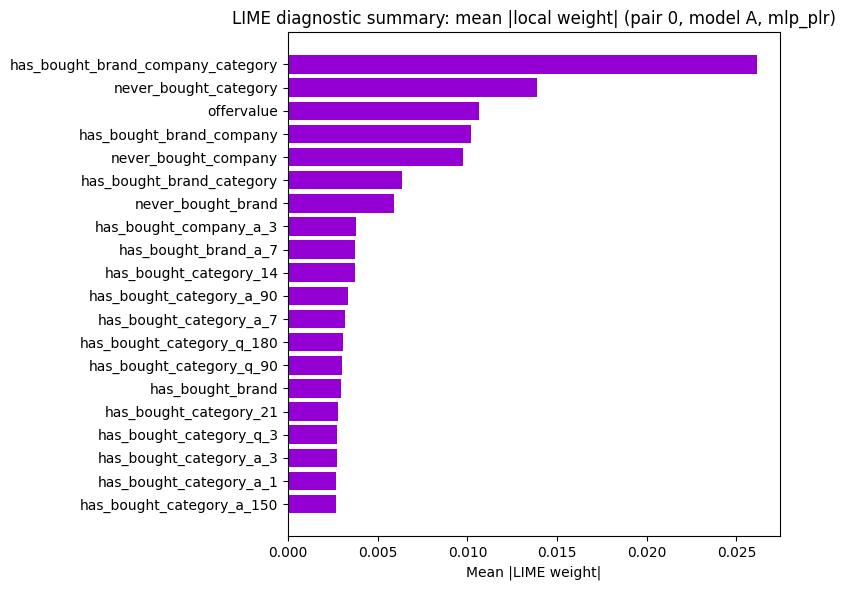

In [16]:
import matplotlib.pyplot as plt

lime_pair0 = LIME_DIR / 'pair_00' / 'lime_A.npy'
if lime_pair0.exists():
    lime_A_0 = np.load(lime_pair0)   # (R, n_lime, p)

    # Replica-averaged attribution per instance
    phi_bar = lime_A_0.mean(axis=0)                 # (n_lime, p)
    global_imp = np.abs(phi_bar).mean(axis=0)       # (p,)

    top_k = 20
    top_idx = np.argsort(global_imp)[::-1][:top_k]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(
        [feature_names[i] for i in top_idx[::-1]],
        global_imp[top_idx[::-1]],
        color='darkviolet'
    )
    ax.set_title(f'LIME diagnostic summary: mean |local weight| (pair 0, model A, {MODEL_TYPE})')
    ax.set_xlabel('Mean |LIME weight|')
    plt.tight_layout()
    plt.savefig(LIME_DIR / 'lime_summary_pair00_A.png', dpi=120)
    plt.show()
else:
    print(f'{lime_pair0} not found — skip summary plot.')
